# Notebook for Batch Loading, Sorting, and Plotting the output of PDFgetx3

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd 
from scipy.ndimage import gaussian_filter1d

import trxrd

%matplotlib widget

## Define Path and Scan Name

In [3]:
DATA_PATH = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\WO3_surv5\output")
SCAN_NAME = "WO3_60nmS1_220K100powsurv5"

## Load the Data

In [4]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}*.gr"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

485 TIFF files found in C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\WO3_surv5\output.


485 .gr files found in C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\WO3_surv5\output


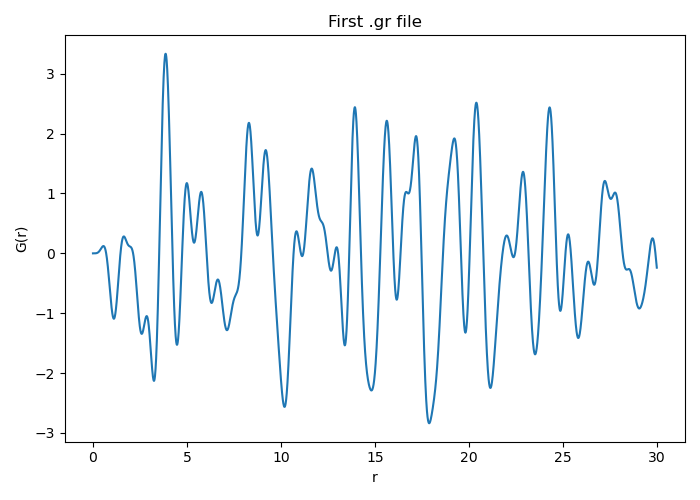

In [5]:
gr_dict = trxrd.get_gr_details(
    folder_path=DATA_PATH,
    sample_name=SCAN_NAME,
    filename_scheme="delay_scan",
    sort=True,
    filter_data=False,
    delay_sign=-1,
    plot=True,
)

r = gr_dict["r"]           # shape (Nr,)
grs = gr_dict["grs"]       # shape (Nfiles, Nr)
delay = gr_dict["delay"]   # shape (Nfiles,)

# gr_dict = trxrd.get_grs_by_scan_name(
#     folder_path=DATA_PATH)

## Compute Reference G(r) and Make dG(r)s

In [6]:
ref_result = trxrd.make_reference_gr(
    grs=gr_dict["grs"],
    delays=gr_dict["delay"],
    reference_selector=None,   # defaults to delays < 0
    return_dict=True,
)

delta_result = trxrd.compute_delta_grs(
    grs=gr_dict["grs"],
    reference_gr=ref_result["reference_gr"],
    mode="subtract",
    delays=gr_dict["delay"],
    r=gr_dict["r"],
    file_names=gr_dict["file_names"],
    scan_number=gr_dict["scan_number"],
    sample_name=gr_dict["sample_name"],
    fluence=gr_dict["fluence"],
    return_dict=True,
)

delta_grs = delta_result["delta_grs"]
reference_gr = ref_result["reference_gr"]

In [31]:
# np.savetxt(f"{SCAN_NAME}_reference_gr.txt", np.column_stack((r, reference_gr)), header="r\tg(r)")

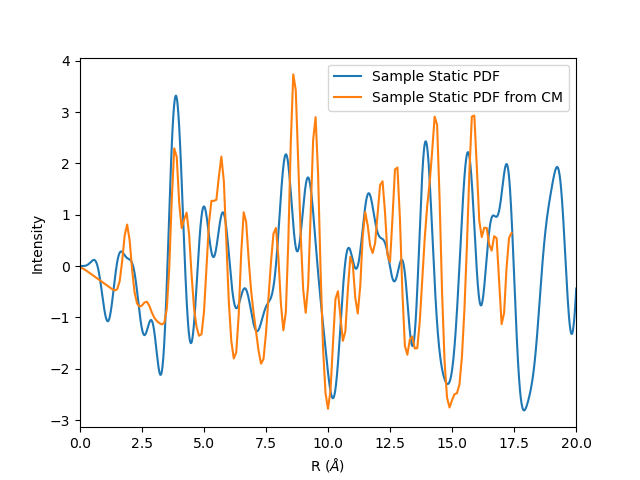

In [13]:
r_vals_cm, pdf_vals_cm = np.loadtxt(f"{DATA_PATH}/WO3_pdf_cm.txt", skiprows=3, unpack=True)


dr = r_vals_cm[1] - r_vals_cm[0]
pdf_smooth_cm = gaussian_filter1d(pdf_vals_cm, sigma=1.5)


plt.figure()
plt.plot(r, reference_gr, label="Sample Static PDF")
plt.plot(r_vals_cm, pdf_smooth_cm/15, label="Sample Static PDF from CM")
plt.xlim(0,20)
plt.xlabel(r"R ($\AA$)")
plt.ylabel("Intensity")
plt.legend()
plt.show()

In [33]:
delta_result.keys()

dict_keys(['delta_grs', 'reference_gr', 'mode', 'delay', 'r', 'file_names', 'scan_number', 'sample_name', 'fluence'])

## Average by Delay

In [14]:
avg_dgr_dict = trxrd.average_delta_grs_by_delay(delta_result, return_dict=True)

print(avg_dgr_dict.keys())
print("Grouped G(r) shape:", avg_dgr_dict["delta_grs"].shape)
print("Grouped std shape:", avg_dgr_dict["std_delta_grs"].shape)
print("Unique delays:", avg_dgr_dict["delay"])
print("Counts per delay:", avg_dgr_dict["counts_per_delay"])

dict_keys(['delta_grs', 'std_delta_grs', 'delay', 'counts_per_delay', 'indices_by_delay', 'grouped_file_names', 'grouped_scan_numbers', 'r'])
Grouped G(r) shape: (6, 3001)
Grouped std shape: (6, 3001)
Unique delays: [-8.e-08 -1.e-08  1.e-10  2.e-10  1.e-09  1.e-07]
Counts per delay: [81 80 81 81 81 81]


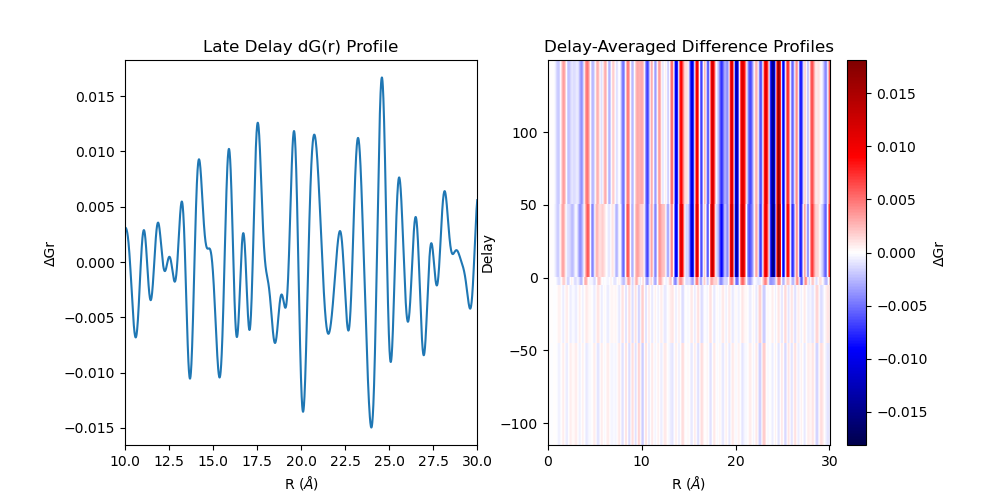

In [15]:
# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(avg_dgr_dict["r"], avg_dgr_dict["delta_grs"][-1], label="Mean Profile")
plt.xlim(10,30)
plt.xlabel(r"R ($\AA$)")
plt.ylabel("ΔGr")       
plt.title("Late Delay dG(r) Profile")

plt.subplot(1,2,2)
plt.pcolormesh(avg_dgr_dict["r"], avg_dgr_dict["delay"]*1e9, avg_dgr_dict["delta_grs"], shading="auto", cmap="seismic")
plt.colorbar(label="ΔGr")

#plt.ylim(-2e-8, 1e-8)
plt.clim(-np.nanmax(avg_dgr_dict["delta_grs"]), np.nanmax(avg_dgr_dict["delta_grs"]))  # set color limits for better contrast; adjust as needed
plt.xlabel(r"R ($\AA$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

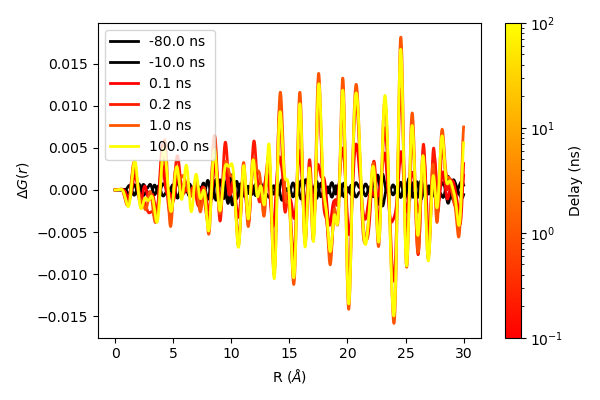

In [16]:
r = avg_dgr_dict["r"]

delays = avg_dgr_dict["delay"]*1e9 # ns
indices = np.arange(0, len(delays))

# Use log scale but handle negative delay separately
norm = mcolors.LogNorm(vmin=0.1, vmax=delays.max())
cmap = cm.autumn

fig, ax = plt.subplots(figsize=(6,4))

for i, d in enumerate(delays):
    # handle negative delay (plot in gray or separate color)
    if d < 0:
        color = "black"
    else:
        color = cmap(norm(d))
    
    ax.plot(
        r,
        avg_dgr_dict["delta_grs"][indices[i]],
        color=color,
        linewidth=2,
        label=f"{d} ns"
    )

# Proper colorbar attachment
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required for matplotlib
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Delay (ns)")

ax.set_xlabel(r"R ($\AA$)")
ax.set_ylabel(r"$\Delta G(r)$")
ax.legend()
# ax.set_xlim(0, 5)
# ax.set_ylim(-0.01, 0.01)

plt.tight_layout()
plt.show()

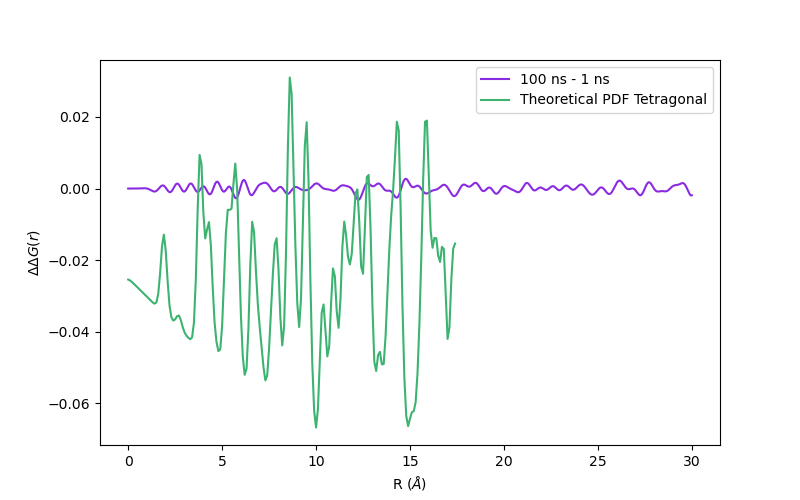

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(r, avg_dgr_dict["delta_grs"][-1]-avg_dgr_dict["delta_grs"][-2], color="blueviolet", label="100 ns - 1 ns")
# plt.plot(r, avg_dgr_dict["delta_grs"][5], label="100 ns", color="mediumseagreen", alpha=0.5)
# plt.plot(r, avg_dgr_dict["delta_grs"][4], label="1 ns", color="lightcoral", alpha=0.5)
plt.plot(r_vals_cm, pdf_smooth_cm/1000 - 0.025, color="mediumseagreen", label="Theoretical PDF Tetragonal")
#plt.plot(r_vals_mono, pdf_mono_smooth/10000, color="salmon", label="Theoretical PDF Monoclinic")
plt.xlabel(r"R ($\AA$)")
plt.ylabel(r"$\Delta\Delta G(r)$")
plt.legend()
plt.show()

In [38]:
df = pd.read_csv("BaTiO3_deltaGr_profile.csv")
df.keys()

Index(['r', 'dGr_late', 'dGr_early'], dtype='str')

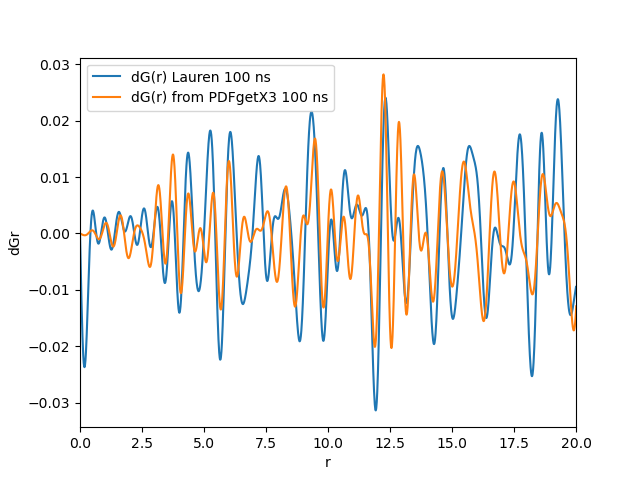

In [39]:
plt.figure()
plt.plot(df["r"], df["dGr_late"]*6, label="dG(r) Lauren 100 ns")
# plt.plot(df["r"], df["dGr_0"]*10, label="Early Calculated dG(r) Lauren")
plt.plot(avg_dgr_dict["r"], avg_dgr_dict["delta_grs"][-1], label="dG(r) from PDFgetX3 100 ns")
# plt.plot(avg_dgr_dict["r"], avg_dgr_dict["delta_grs"][0], label="Early dG(r) from PDFgetX3")
plt.xlabel("r")
plt.ylabel("dGr")
plt.legend()
plt.xlim(0, 20)
plt.show()

## Average G(r) by Delay

In [20]:
delays

array([-80. , -10. ,   0.1,   0.2,   1. , 100. ])

In [21]:
avg_gr_dict = trxrd.average_profiles_by_delay(grs, delay, return_dict=True)


for i, profile in enumerate(avg_gr_dict["mean_profiles"]):
    np.savetxt(DATA_PATH/f"WO3_{delays[i]}_gr.gr", np.column_stack((r, profile)), header="r\tg(r)")



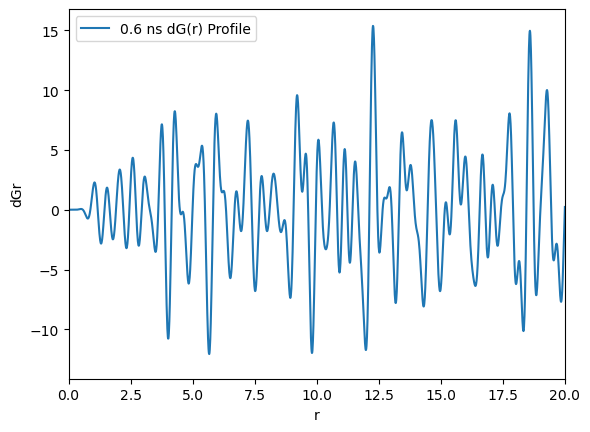

In [ ]:
plt.figure()
plt.plot(r, avg_dgr_dict["delta_grs"][2]*500, label="0.6 ns dG(r) Profile")
plt.xlabel("r")
plt.ylabel("dGr")
plt.legend()
plt.xlim(0, 20)
plt.show()